In [331]:
# Imports
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm  # OLS summary (p-values, confidence intervals)

In [332]:
import pandas as pd
import glob
import os

# 1. Setup the path where you extracted the files
# Put all your .csv files in a folder named 'data'
path = './data' 
all_files = glob.glob(os.path.join(path, "*.csv"))

# 2. List to hold dataframes
df_list = []

for filename in all_files:
    # Read the file
    df_temp = pd.read_csv(filename)
    
    # Extract the brand name from the file name (e.g., 'bmw.csv' -> 'bmw')
    brand_name = os.path.basename(filename).replace('.csv', '')
    df_temp['brand'] = brand_name
    
    df_list.append(df_temp)

# 3. Concatenate everything into one Master Dataframe
master_df = pd.concat(df_list, axis=0, ignore_index=True)

# 4. Save the Master File for your VS Code project
master_df.to_csv('master_car_listings.csv', index=False)

print(f"Master file created! Total observations: {len(master_df)}")
    
# Standardize column names
master_df.columns = master_df.columns.str.lower()
    
print(f" Load successful: {master_df.shape[0]} rows, {master_df.shape[1]} columns.")
display(master_df.head(30))

print(f"Total observations in master_df: {len(master_df)}")

Master file created! Total observations: 99187
 Load successful: 99187 rows, 11 columns.


,model,year,price,transmission,mileage,fueltype,tax,mpg,enginesize,brand,tax(£)
0,A1,2017,12500,Manual,15735,Petrol,150.0,55.4,1.4,audi,NaN
1,A6,2016,16500,Automatic,36203,Diesel,20.0,64.2,2.0,audi,NaN
2,A1,2016,11000,Manual,29946,Petrol,30.0,55.4,1.4,audi,NaN
3,A4,2017,16800,Automatic,25952,Diesel,145.0,67.3,2.0,audi,NaN
4,A3,2019,17300,Manual,1998,Petrol,145.0,49.6,1.0,audi,NaN
5,A1,2016,13900,Automatic,32260,Petrol,30.0,58.9,1.4,audi,NaN
6,A6,2016,13250,Automatic,76788,Diesel,30.0,61.4,2.0,audi,NaN
7,A4,2016,11750,Manual,75185,Diesel,20.0,70.6,2.0,audi,NaN
8,A3,2015,10200,Manual,46112,Petrol,20.0,60.1,1.4,audi,NaN
9,A1,2016,12000,Manual,22451,Petrol,30.0,55.4,1.4,audi,NaN


Total observations in master_df: 99187


## Data Cleaning

In [333]:
# 1. Identify and remove duplicate rows
initial_rows = len(master_df)
master_df = master_df.drop_duplicates()
final_rows = len(master_df)

# 2. Print the result of the cleaning
print(f"Rows before cleaning: {initial_rows}")
print(f"Rows after removing duplicates: {final_rows}")
print(f"Total duplicates removed: {initial_rows - final_rows}")

Rows before cleaning: 99187
Rows after removing duplicates: 97712
Total duplicates removed: 1475


In [334]:
# 1. Calculate the required metrics
# Total rows in the dataframe for percentage calculation
total_rows = len(master_df)

# 2. Build the overview dictionary with the new columns
extended_overview = {
    'Data Type': master_df.dtypes,
    'Total Observations': master_df.count(), # Non-null count
    'Missing Values (NaNs)': master_df.isna().sum(),
    '% Missing Values': (master_df.isna().sum() / total_rows) * 100,
    'Unique Observations': master_df.nunique(),
    'Min Value': master_df.min(numeric_only=True),
    'Max Value': master_df.max(numeric_only=True)
}

# 3. Create the summary DataFrame
tech_overview_v2 = pd.DataFrame(extended_overview)

# 4. Formatting for better readability
# Fill NaN for non-numeric columns and round the percentage
tech_overview_v2['Min Value'] = tech_overview_v2['Min Value'].fillna('-')
tech_overview_v2['Max Value'] = tech_overview_v2['Max Value'].fillna('-')
tech_overview_v2['% Missing Values'] = tech_overview_v2['% Missing Values'].round(2).astype(str) + '%'

# 5. Display the updated table
print(f"Total rows in master_df: {total_rows}")
tech_overview_v2

Total rows in master_df: 97712


,Data Type,Total Observations,Missing Values (NaNs),% Missing Values,Unique Observations,Min Value,Max Value
brand,object,97712,0,0.0%,9,-,-
enginesize,float64,97712,0,0.0%,40,0.0,6.6
fueltype,object,97712,0,0.0%,5,-,-
mileage,int64,97712,0,0.0%,42214,1.0,323000.0
model,object,97712,0,0.0%,195,-,-
mpg,float64,97712,0,0.0%,208,0.3,470.8
price,int64,97712,0,0.0%,13236,450.0,159999.0
tax,float64,92938,4774,4.89%,48,0.0,580.0
tax(£),float64,4774,92938,95.11%,24,0.0,555.0
transmission,object,97712,0,0.0%,4,-,-


The first possible inconsistency that stands out is the presence of two tax variables: tax and tax£. Looking at the missing values percentages, they look like they are mutually exclusive: this makes us think their difference is just a matter of typos. 

Before merging the two variables into one, let's do a quick check of the values distributions to make sure that the values are the same type in both attributes.

In [335]:
# Check if they are mutually exclusive or redundant
print(master_df[['tax', 'tax(£)']].describe())
print(f"Rows with both tax values: {master_df[(master_df['tax'] > 0) & (master_df['tax(£)'] > 0)].shape[0]}")

                tax       tax(£)
count  92938.000000  4774.000000
mean     120.088715   121.187683
std       63.613732    58.135472
min        0.000000     0.000000
25%      125.000000   125.000000
50%      145.000000   145.000000
75%      145.000000   145.000000
max      580.000000   555.000000
Rows with both tax values: 0


The results confirm our hypothesis: the distribution values are almost the same for all of the values showed. We can therefore merge the two variables into one without further hesitation.

In [336]:
# 1. Merge the two columns into 'tax'
# Since they don't overlap, we can sum them after filling NaNs with 0
master_df['tax'] = master_df['tax'].fillna(0) + master_df['tax(£)'].fillna(0)

# 2. Drop the redundant column
master_df = master_df.drop(columns=['tax(£)'])

# 3. Verify the operation
print(f"Total non-null observations in 'tax': {master_df['tax'].count()}")
master_df[['tax']].describe()

Total non-null observations in 'tax': 97712


,tax
count,97712.000000
mean,120.142408
std,63.357250
min,0.000000
25%,125.000000
50%,145.000000
75%,145.000000
max,580.000000


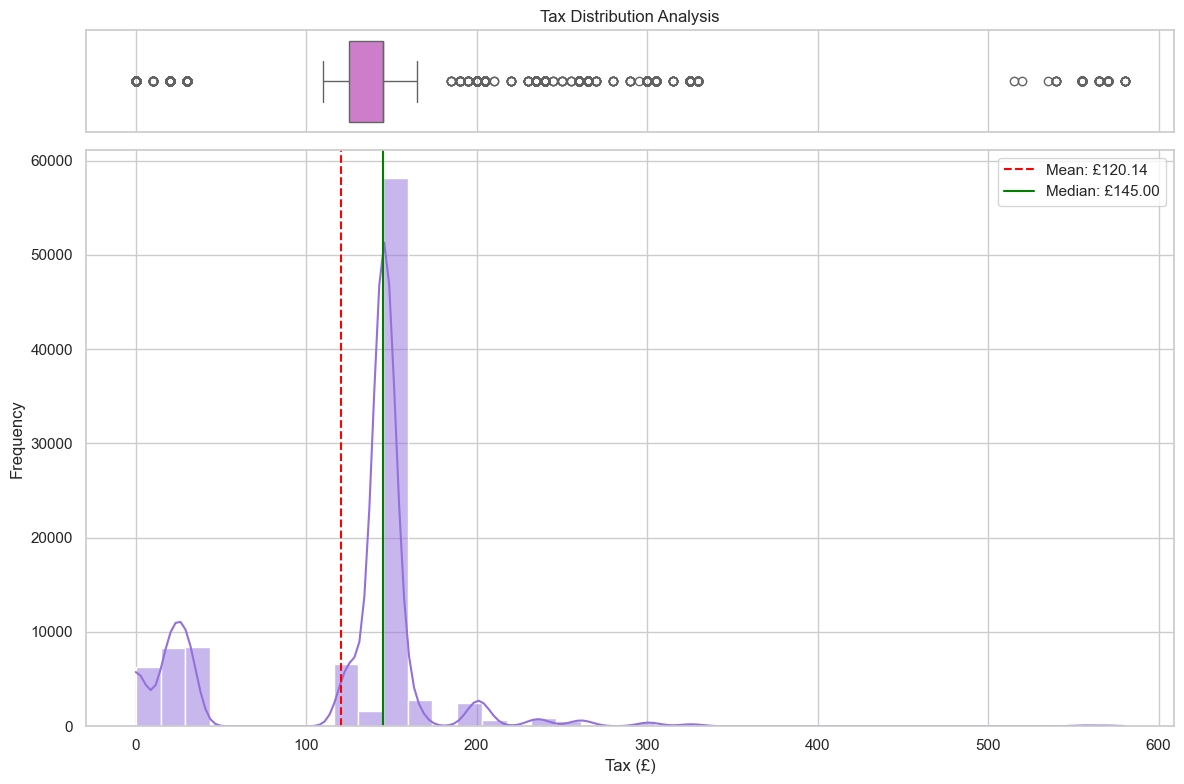

In [337]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set the visual style for the plots
sns.set_theme(style="whitegrid")

# 2. Create a figure with two subplots (Boxplot on top, Histogram below)
# We use sharex=True so they both use the same scale for the tax value
fig, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)}, figsize=(12, 8))

# 3. Create the Box Plot to detect outliers or tax brackets
sns.boxplot(data=master_df, x='tax', ax=ax_box, color='orchid')
ax_box.set(title='Tax Distribution Analysis', xlabel='')

# 4. Create the Histogram with a KDE (Kernel Density Estimate)
# We use a reasonable number of bins to see the specific tax bands
sns.histplot(data=master_df, x='tax', kde=True, ax=ax_hist, color='mediumpurple', bins=40)
ax_hist.set(xlabel='Tax (£)', ylabel='Frequency')

# 5. Add vertical lines for Mean and Median to evaluate the distribution
mean_tax = master_df['tax'].mean()
median_tax = master_df['tax'].median()
plt.axvline(mean_tax, color='red', linestyle='--', label=f"Mean: £{mean_tax:.2f}")
plt.axvline(median_tax, color='green', linestyle='-', label=f"Median: £{median_tax:.2f}")

# 6. Final layout adjustments
plt.legend()
plt.tight_layout()
plt.show()

In [338]:
# Define the tax ranges as requested
# We use absolute filtering to avoid overlaps where specified
ranges = {
    '0 - 10':  master_df[(master_df['tax'] >= 0) & (master_df['tax'] <= 10)],
    '10 - 30': master_df[(master_df['tax'] > 10) & (master_df['tax'] <= 30)],
    '30 - 50': master_df[(master_df['tax'] > 30) & (master_df['tax'] <= 50)],
    '0 - 50':  master_df[(master_df['tax'] >= 0) & (master_df['tax'] <= 50)],
    'Over 200': master_df[master_df['tax'] > 200]
}

total_cars = len(master_df)

# Create a summary table
tax_analysis = []
for label, df_slice in ranges.items():
    count = len(df_slice)
    percentage = (count / total_cars) * 100
    tax_analysis.append({'Range (£)': label, 'Count': count, 'Percentage (%)': round(percentage, 2)})

tax_summary_df = pd.DataFrame(tax_analysis)
print(f"Tax Bracket Distribution (Total Cars: {total_cars})")
display(tax_summary_df)

Tax Bracket Distribution (Total Cars: 97712)


,Range (£),Count,Percentage (%)
0,0 - 10,6284,6.43
1,10 - 30,16671,17.06
2,30 - 50,0,0.00
3,0 - 50,22955,23.49
4,Over 200,3175,3.25


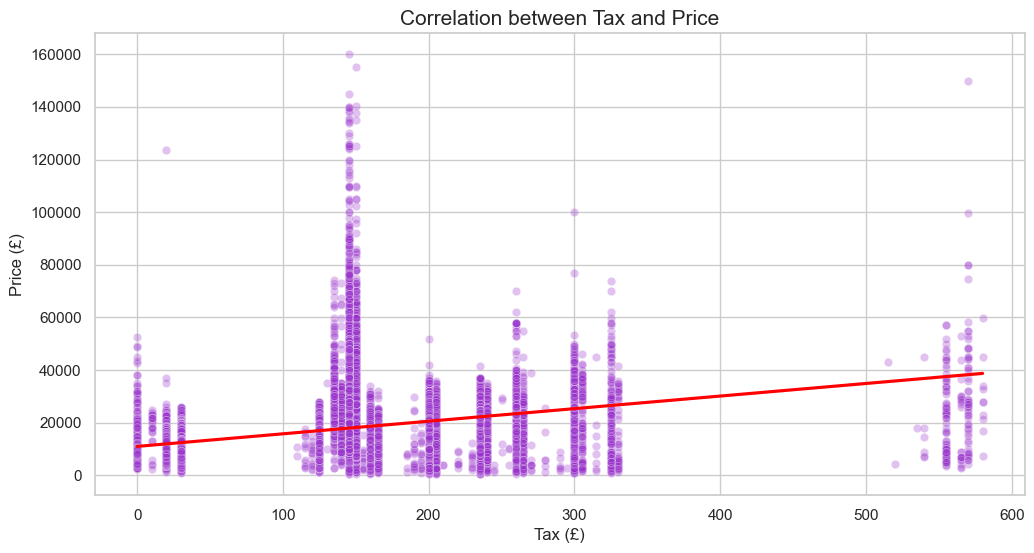

In [339]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Visualizing the relationship between Tax and Price
plt.figure(figsize=(12, 6))
sns.scatterplot(data=master_df, x='tax', y='price', alpha=0.3, color='darkorchid')

# 2. Adding a regression line to see the trend
sns.regplot(data=master_df, x='tax', y='price', scatter=False, color='red')

plt.title('Correlation between Tax and Price', fontsize=15)
plt.xlabel('Tax (£)', fontsize=12)
plt.ylabel('Price (£)', fontsize=12)
plt.show()

In [340]:
# 1. Remove cars with a tax higher than £500
# These records often represent high-emission luxury vehicles or 
# specific tax brackets that act as outliers for a mid-range model.
initial_rows = len(master_df)
master_df = master_df[master_df['tax'] <= 500]

# 2. Calculate and output the impact of the cleaning
rows_deleted = initial_rows - len(master_df)
print(f"Cleaning step finished. Removed {rows_deleted} tax outliers.")
print(f"Current dataset size: {len(master_df)} rows.")

# 3. Final verification of the tax upper bound
print(f"New maximum tax value in the dataset: £{master_df['tax'].max()}")

Cleaning step finished. Removed 176 tax outliers.
Current dataset size: 97536 rows.
New maximum tax value in the dataset: £330.0


Let's move on to the variable brand: let's check if all the values are consistent.

In [341]:
# 1. Get the list of all unique brands
unique_brands = master_df['brand'].unique()

# 2. Get the count of observations for each brand to see the distribution
brand_distribution = master_df['brand'].value_counts()

# 3. Display the results
print("Unique brands in the dataset:")
print(unique_brands)
print("\nNumber of cars per brand:")
print(brand_distribution)

Unique brands in the dataset:
['audi' 'bmw' 'ford' 'hyundi' 'merc' 'skoda' 'toyota' 'vauxhall' 'vw']

Number of cars per brand:
brand
ford        17799
vw          14887
vauxhall    13253
merc        12791
bmw         10624
audi        10525
toyota       6696
skoda        6188
hyundi       4773
Name: count, dtype: int64


Just for spelling purposes and overall clarity, some of the brands are renamed.

In [342]:
# 1. Create a mapping dictionary for the corrections
# Based on the unique values identified in the previous step
brand_mapping = {
    'vw': 'volkswagen',
    'hyundi': 'hyundai',
    'merc': 'mercedes'
}

# 2. Replace the values in the 'brand' column
master_df['brand'] = master_df['brand'].replace(brand_mapping)

# 3. Verify that the transformation was successful
print("Updated unique brands list:")
print(master_df['brand'].unique())

Updated unique brands list:
['audi' 'bmw' 'ford' 'hyundai' 'mercedes' 'skoda' 'toyota' 'vauxhall'
 'volkswagen']


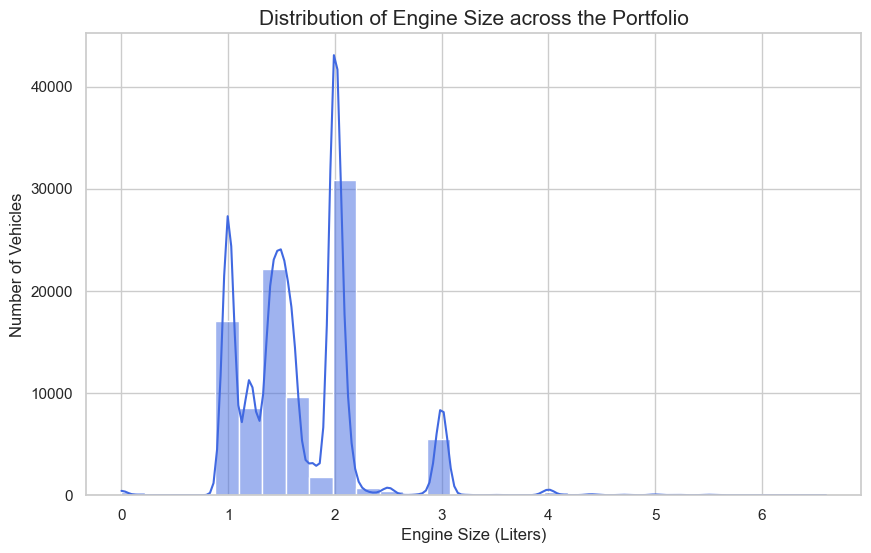

In [343]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set the visual style of the plots
sns.set_theme(style="whitegrid")

# 2. Create the histogram for engine size
# We use a larger figure size to ensure labels are readable
plt.figure(figsize=(10, 6))
sns.histplot(master_df['enginesize'], bins=30, kde=True, color='royalblue')

# 3. Add clear labels and title
# Ensuring no overlap and professional look
plt.title('Distribution of Engine Size across the Portfolio', fontsize=15)
plt.xlabel('Engine Size (Liters)', fontsize=12)
plt.ylabel('Number of Vehicles', fontsize=12)

# 4. Show the plot
plt.show()

In [344]:
# 1. Remove all records with engine size < 0.6
# Based on the previous check, 0 electric vehicles are in this range,
# so we can safely remove these 268 data entry errors (Petrol, Diesel, Hybrid).
initial_count = len(master_df)
master_df = master_df[master_df['enginesize'] >= 0.6]

# 2. Calculate and print the impact of the cleaning
removed_rows = initial_count - len(master_df)
print(f"Rows removed: {removed_rows}")
print(f"New total observations: {len(master_df)}")

# 3. Verify the new minimum engine size
# It should now be at least 0.6L or 1.0L
print(f"New minimum engine size: {master_df['enginesize'].min()}L")

Rows removed: 266
New total observations: 97270
New minimum engine size: 0.6L


In [345]:
# Block 2: Investigating very large engine sizes
# Filter for engine size above 5.0
large_engines = master_df[master_df['enginesize'] > 5.0]

print(f"Total records with engine size > 5.0: {len(large_engines)}")
if len(large_engines) > 0:
    # Display the models to check if they are high-performance vehicles (e.g., AMG, M-Series)
    display(large_engines[['brand', 'model', 'enginesize', 'fueltype']].value_counts().to_frame())
else:
    print("No records found in this range.")

Total records with engine size > 5.0: 46


count
brand    model     enginesize fueltype       
audi     R8        5.2        Petrol       18
mercedes GLE Class 5.5        Petrol       10
         SL CLASS  5.5        Petrol        9
         GLS Class 5.5        Petrol        3
bmw      7 Series  6.6        Petrol        2
mercedes G Class   5.5        Petrol        1
         CL Class  5.4        Petrol        1
         S Class   5.5        Petrol        1
                   6.0        Petrol        1

In [346]:
# 1. Get the list of all unique fuel types
unique_fuels = master_df['fueltype'].unique()

# 2. Get the count of observations for each fuel type
# This helps identify if some categories are too rare or are typos
fuel_distribution = master_df['fueltype'].value_counts()

# 3. Display the results
print("Unique fuel types in the dataset:")
print(unique_fuels)
print("\nNumber of cars per fuel type:")
print(fuel_distribution)

Unique fuel types in the dataset:
['Petrol' 'Diesel' 'Hybrid' 'Other' 'Electric']

Number of cars per fuel type:
fueltype
Petrol      53684
Diesel      40316
Hybrid       3021
Other         245
Electric        4
Name: count, dtype: int64


In [347]:
# 1. Define the replacement mapping
# We merge 'Electric' into 'Other' due to very low frequency (6 observations)
fuel_mapping = {
    'Electric': 'Other'
}

# 2. Apply the change to the fueltype column
master_df['fueltype'] = master_df['fueltype'].replace(fuel_mapping)

# 3. Verify the new distribution
print("Updated distribution of fuel types:")
print(master_df['fueltype'].value_counts())

Updated distribution of fuel types:
fueltype
Petrol    53684
Diesel    40316
Hybrid     3021
Other       249
Name: count, dtype: int64


Luckily only one row contains an impossible year. We can delete this row from the dataset without hesitation.

In [348]:
# 1. Get unique values and their absolute frequency
transmission_counts = master_df['transmission'].value_counts()

# 2. Calculate the percentage for each category
transmission_pct = master_df['transmission'].value_counts(normalize=True) * 100

# 3. Combine into a single summary table
transmission_summary = pd.DataFrame({
    'Count': transmission_counts,
    'Percentage (%)': transmission_pct.round(2)
})

# 4. Display the results
print("Transmission types and frequencies:")
display(transmission_summary)

Transmission types and frequencies:


,Count,Percentage (%)
transmission,,
Manual,55324,56.88
Semi-Auto,22252,22.88
Automatic,19686,20.24
Other,8,0.01


In [349]:
# 1. Identify and remove rows where transmission is 'Other'
# Given there are only 8 such observations (0.01%), they are statistically insignificant
initial_count = len(master_df)
master_df = master_df[master_df['transmission'] != 'Other']

# 2. Calculate and print the impact
removed_rows = initial_count - len(master_df)
print(f"Rows removed (transmission 'Other'): {removed_rows}")
print(f"Final dataset size: {len(master_df)} rows")

# 3. Quick verification of remaining categories
print("\nRemaining transmission types:")
print(master_df['transmission'].value_counts())

Rows removed (transmission 'Other'): 8
Final dataset size: 97262 rows

Remaining transmission types:
transmission
Manual       55324
Semi-Auto    22252
Automatic    19686
Name: count, dtype: int64


## Miles per gallon

In [350]:
# 1. Define the conversion factor (UK Gallons to Liters and Miles to KM)
# 1 mile = 1.60934 km
# 1 gallon (UK) = 4.54609 liters
conversion_factor = 1.60934 / 4.54609

# 2. Create the new column 'km_l'
master_df['km_per_litre'] = master_df['mpg'] * conversion_factor
master_df['km_per_litre'] = master_df['km_per_litre'].astype(int)

# 3. Analyze extreme values for the new variable
print("Technical Overview of km_l:")
print(master_df['km_per_litre'].describe())

Technical Overview of km_l:
count    97262.000000
mean        19.007218
std          5.005627
min          0.000000
25%         16.000000
50%         19.000000
75%         22.000000
max        166.000000
Name: km_per_litre, dtype: float64


In [351]:
# 1. Define the range limits in km/l
lower_limit = 4.0
upper_limit = 100.0

# 2. Identify rows outside the range
# We consider both the very low (errors) and the very high (impossible/extreme)
outliers_lower = master_df[master_df['km_per_litre'] < lower_limit]
outliers_upper = master_df[master_df['km_per_litre'] > upper_limit]

# 3. Calculate counts
count_low = len(outliers_lower)
count_high = len(outliers_upper)
total_outliers = count_low + count_high

# 4. Display the results
print(f"Analysis of Fuel Efficiency Outliers ({lower_limit} - {upper_limit} km/l):")
print(f"- Rows below {lower_limit} km/l: {count_low}")
print(f"- Rows above {upper_limit} km/l: {count_high}")
print(f"- Total rows to be removed: {total_outliers}")
print(f"- Impact on dataset: {(total_outliers / len(master_df) * 100):.4f}%")

# Show a sample of the most extreme values to confirm they are errors
if total_outliers > 0:
    print("\nSample of extreme outliers (sorted by km_l):")
    display(pd.concat([outliers_lower, outliers_upper]).sort_values(by='km_per_litre')[['brand', 'model', 'year', 'mpg', 'km_per_litre']].head(10))

Analysis of Fuel Efficiency Outliers (4.0 - 100.0 km/l):
- Rows below 4.0 km/l: 34
- Rows above 100.0 km/l: 8
- Total rows to be removed: 42
- Impact on dataset: 0.0432%

Sample of extreme outliers (sorted by km_l):


,brand,model,year,mpg,km_per_litre
40222,hyundai,Ioniq,2020,1.1,0
39624,hyundai,Ioniq,2019,1.1,0
70256,toyota,Hilux,2020,2.8,0
70255,toyota,Hilux,2019,2.8,0
70236,toyota,Hilux,2019,2.8,0
70235,toyota,Hilux,2019,2.8,0
70254,toyota,Hilux,2020,2.8,0
70243,toyota,Hilux,2019,2.8,0
70222,toyota,Hilux,2020,2.8,0
70223,toyota,Hilux,2020,2.8,0


In [352]:
# Sorting by km_l descending to see the most extreme values first
display(outliers_upper[['brand', 'model', 'year', 'fueltype', 'mpg', 'km_per_litre']].sort_values(by='km_per_litre', ascending=False))

,brand,model,year,fueltype,mpg,km_per_litre
10700,bmw,i3,2016,Other,470.8,166
18856,bmw,i3,2015,Other,470.8,166
19288,bmw,i3,2017,Other,470.8,166
19503,bmw,i3,2015,Other,470.8,166
20748,bmw,i3,2017,Other,470.8,166
20754,bmw,i3,2017,Other,470.8,166
20993,bmw,i3,2016,Other,470.8,166
21198,bmw,i3,2017,Other,470.8,166


In [353]:
# 1. Final cleaning of the dataset
# We remove the 42 fuel efficiency outliers (including the 8 BMW i3 REx)
# and the record with the year 2060.
initial_count = len(master_df)

# Applying fuel efficiency limits (4.0 - 100.0 km/l)
master_df = master_df[(master_df['km_per_litre'] >= 4.0) & (master_df['km_per_litre'] <= 100.0)]

# 2. Final verification
removed_total = initial_count - len(master_df)
print(f"Cleaning complete. Total rows removed in this step: {removed_total}")
print(f"Final dataset size: {len(master_df)} rows")

# 3. Check new max/min values to ensure consistency
print("\nFinal Bounds Check:")
print(f"- Year Range: {master_df['year'].min()} to {master_df['year'].max()}")
print(f"- Efficiency Range: {master_df['km_per_litre'].min():.2f} to {master_df['km_per_litre'].max():.2f} km/l")

Cleaning complete. Total rows removed in this step: 42
Final dataset size: 97220 rows

Final Bounds Check:
- Year Range: 1970 to 2060
- Efficiency Range: 6.00 to 90.00 km/l


In [354]:
# Remove the redundant 'mpg' column since we successfully converted it to 'km_l'
master_df = master_df.drop(columns=['mpg'])

# Verify the current columns in the dataframe
print("Updated list of columns:")
print(master_df.columns.tolist())

Updated list of columns:
['model', 'year', 'price', 'transmission', 'mileage', 'fueltype', 'tax', 'enginesize', 'brand', 'km_per_litre']


In [355]:
# 1. Locate the observation(s) with impossible years
future_cars = master_df[master_df['year'] > 2020]

print(f"Number of cars from the future: {len(future_cars)}")
display(future_cars)

Number of cars from the future: 1


,model,year,price,transmission,mileage,fueltype,tax,enginesize,brand,km_per_litre
39175,Fiesta,2060,6495,Automatic,54807,Petrol,205.0,1.4,ford,15


In [356]:
# 2. Remove them from the dataset
master_df = master_df[master_df['year'] <= 2020]

# 3. Verify the new maximum year
print(f"New maximum year in dataset: {master_df['year'].max()}")

New maximum year in dataset: 2020


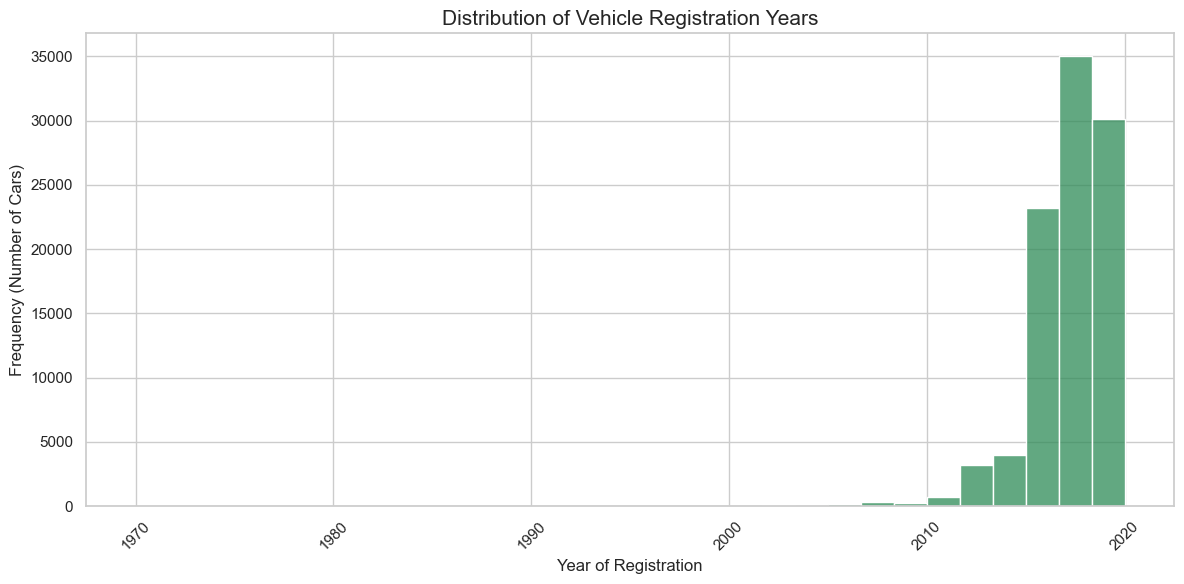

In [357]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set the visual style
sns.set_theme(style="whitegrid")

# 2. Create the histogram for the 'year' variable
plt.figure(figsize=(12, 6))

# We use bins corresponding to the number of years or a fixed number 
# to see the annual distribution clearly.
sns.histplot(master_df['year'], bins=30, kde=False, color='seagreen')

# 3. Add professional labeling
plt.title('Distribution of Vehicle Registration Years', fontsize=15)
plt.xlabel('Year of Registration', fontsize=12)
plt.ylabel('Frequency (Number of Cars)', fontsize=12)

# 4. Adjust x-axis to show years more clearly if needed
plt.xticks(rotation=45)

# 5. Display the plot
plt.tight_layout()
plt.show()

In [358]:
# 1. Split the dataset into two groups: pre-2010 and post-2010
pre_2010 = master_df[master_df['year'] < 2010]
post_2010 = master_df[master_df['year'] >= 2010]

# 2. Calculate absolute frequencies and percentages
count_pre = len(pre_2010)
count_post = len(post_2010)
total = len(master_df)

# 3. Display the results
print(f"Analysis of Vehicle Age Distribution:")
print(f"- Cars produced BEFORE 2010: {count_pre} ({(count_pre/total*100):.2f}%)")
print(f"- Cars produced FROM 2010 onwards: {count_post} ({(count_post/total*100):.2f}%)")

Analysis of Vehicle Age Distribution:
- Cars produced BEFORE 2010: 907 (0.93%)
- Cars produced FROM 2010 onwards: 96312 (99.07%)


In [359]:
# 1. Keep only vehicles registered from 2010 onwards
# This removes 958 rows identified as noise (0.98% of the total)
initial_rows = len(master_df)
master_df = master_df[master_df['year'] >= 2010]

# 2. Calculate the impact of this operation
deleted_rows = initial_rows - len(master_df)
print(f"Cleaning complete: {deleted_rows} older records removed.")
print(f"Final dataset consistency: {len(master_df)} total observations.")

# 3. Quick check to verify the new temporal boundaries
print(f"New temporal range: {master_df['year'].min()} to {master_df['year'].max()}")

Cleaning complete: 907 older records removed.
Final dataset consistency: 96312 total observations.
New temporal range: 2010 to 2020


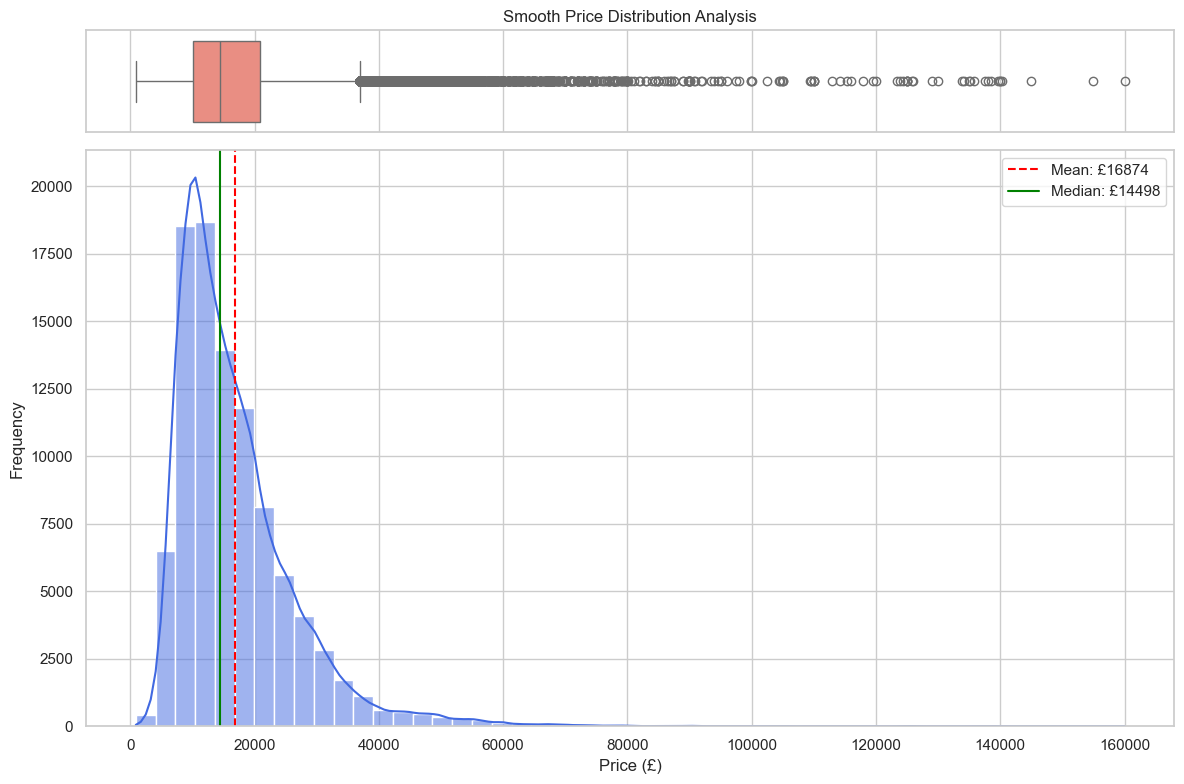

In [360]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set the visual style and figure layout
sns.set_theme(style="whitegrid")
fig, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)}, figsize=(12, 8))

# 2. Box Plot (remains the same to highlight outliers)
sns.boxplot(data=master_df, x='price', ax=ax_box, color='salmon')
ax_box.set(title='Smooth Price Distribution Analysis', xlabel='')

# 3. Histogram with larger intervals (bins=50) to remove the "stepped" look
# Decreasing the number of bins makes the distribution look smoother.
sns.histplot(data=master_df, x='price', kde=True, ax=ax_hist, color='royalblue', bins=50)
ax_hist.set(xlabel='Price (£)', ylabel='Frequency')

# 4. Vertical lines for Mean and Median
mean_p = master_df['price'].mean()
median_p = master_df['price'].median()
plt.axvline(mean_p, color='red', linestyle='--', label=f"Mean: £{mean_p:.0f}")
plt.axvline(median_p, color='green', linestyle='-', label=f"Median: £{median_p:.0f}")

# 5. Final touches
plt.legend()
plt.tight_layout()
plt.show()

In [361]:
# 1. Define the possible upper thresholds
thresholds = [50000, 60000, 80000, 100000]
lower_limit = 2000

print(f"Total cars in dataset: {len(master_df)}")
print(f"Cars below £{lower_limit}: {len(master_df[master_df['price'] < lower_limit])}")

# 2. Loop through thresholds to see the impact
for t in thresholds:
    count = len(master_df[master_df['price'] > t])
    percentage = (count / len(master_df)) * 100
    print(f"Cars above £{t}: {count} ({percentage:.2f}%)")

# 3. View a sample of the most expensive cars remaining
print("\nSample of cars above £60,000:")
display(master_df[master_df['price'] > 60000][['brand', 'model', 'year', 'enginesize', 'price']].sort_values(by='price', ascending=False).head(10))

Total cars in dataset: 96312
Cars below £2000: 19
Cars above £50000: 1120 (1.16%)
Cars above £60000: 410 (0.43%)
Cars above £80000: 90 (0.09%)
Cars above £100000: 46 (0.05%)

Sample of cars above £60,000:


,brand,model,year,enginesize,price
50473,mercedes,G Class,2020,4.0,159999
54318,mercedes,G Class,2020,4.0,154998
4783,audi,R8,2020,5.2,145000
53011,mercedes,A Class,2019,4.0,140319
50660,mercedes,G Class,2018,4.0,139995
44282,mercedes,G Class,2019,4.0,139948
53407,mercedes,A Class,2019,4.0,139559
53095,mercedes,A Class,2020,4.0,138439
2255,audi,R8,2020,5.2,137995
4179,audi,R8,2019,5.2,137500


In [362]:
# 1. Filter the dataset by price
# We are removing 1,135 cars above £50,000 and 19 cars below £2,000
# to eliminate extreme noise and focus on the core market.
initial_count = len(master_df)
master_df = master_df[(master_df['price'] >= 2000) & (master_df['price'] <= 50000)]

# 2. Calculate and print the impact
removed_rows = initial_count - len(master_df)
print(f"Price cleaning complete. Total rows removed: {removed_rows}")
print(f"Final dataset size: {len(master_df)} rows.")

# 3. Verify the final price boundaries
print(f"Final price range: £{master_df['price'].min()} - £{master_df['price'].max()}")

Price cleaning complete. Total rows removed: 1139
Final dataset size: 95173 rows.
Final price range: £2195 - £50000


In [364]:
# 1. Convert mileage from miles to kilometers
# Conversion factor: 1 mile = 1.609344 km
master_df['mileage_km'] = master_df['mileage'] * 1.609344

# 2. Transform the float values into integers
# We remove decimals as they are not significant for mileage analysis
master_df['mileage_km'] = master_df['mileage_km'].astype(int)

# 3. Remove the original 'mileage' column to maintain a clean dataset
master_df = master_df.drop(columns=['mileage'])

# 4. Verify the transformation
print("Column successfully converted, rounded to integer, and renamed to 'mileage_km'.")
display(master_df[['brand', 'model', 'year', 'mileage_km']].head())

# 5. Check the new distribution boundaries in kilometers
print("\nNew Mileage Stats (in km):")
print(f"- Min: {master_df['mileage_km'].min()} km")
print(f"- Max: {master_df['mileage_km'].max()} km")
print(f"- Mean: {master_df['mileage_km'].mean():.0f} km")

Column successfully converted, rounded to integer, and renamed to 'mileage_km'.


,brand,model,year,mileage_km
0,audi,A1,2017,25323
1,audi,A6,2016,58263
2,audi,A1,2016,48193
3,audi,A4,2017,41765
4,audi,A3,2019,3215



New Mileage Stats (in km):
- Min: 1 km
- Max: 387037 km
- Mean: 36638 km


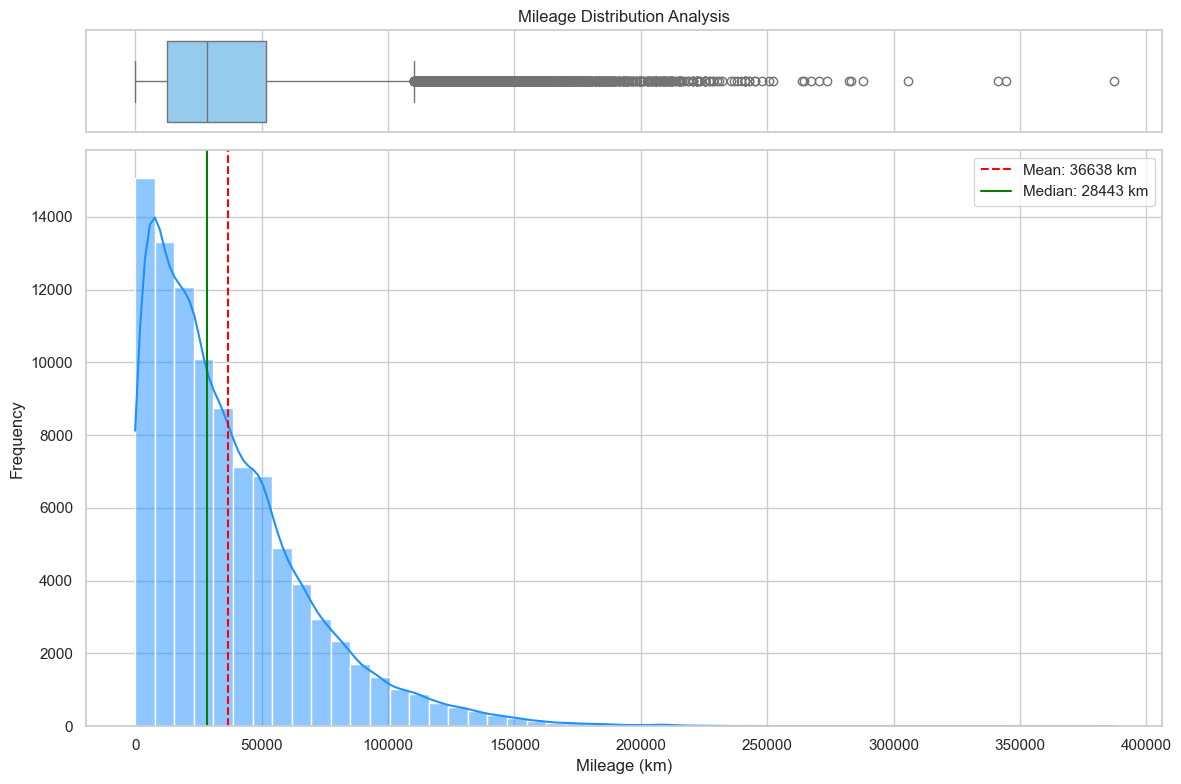

In [365]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set the visual style
sns.set_theme(style="whitegrid")

# 2. Create a figure with two subplots (Boxplot and Histogram)
# This allows us to see the distribution shape and outliers simultaneously
fig, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)}, figsize=(12, 8))

# 3. Create the Box Plot
sns.boxplot(data=master_df, x='mileage_km', ax=ax_box, color='lightskyblue')
ax_box.set(title='Mileage Distribution Analysis', xlabel='')

# 4. Create the Histogram with KDE
# We use bins=50 for a balanced level of detail
sns.histplot(data=master_df, x='mileage_km', kde=True, ax=ax_hist, color='dodgerblue', bins=50)
ax_hist.set(xlabel='Mileage (km)', ylabel='Frequency')

# 5. Add vertical lines for Mean and Median
mean_m = master_df['mileage_km'].mean()
median_m = master_df['mileage_km'].median()
plt.axvline(mean_m, color='red', linestyle='--', label=f"Mean: {mean_m:.0f} km")
plt.axvline(median_m, color='green', linestyle='-', label=f"Median: {median_m:.0f} km")

# 6. Final adjustments
plt.legend()
plt.tight_layout()
plt.show()

In [366]:
# 1. Filter the dataset for cars with more than 150,000 km
km_threshold = 150000
very_high_mileage = master_df[master_df['mileage_km'] > km_threshold]

# 2. Calculate absolute and percentage frequency
count_extreme = len(very_high_mileage)
total_rows = len(master_df)
percentage_extreme = (count_extreme / total_rows) * 100

# 3. Print the results
print(f"Analysis of vehicles with > {km_threshold:,} km:")
print(f"- Absolute frequency: {count_extreme} cars")
print(f"- Percentage of dataset: {percentage_extreme:.2f}%")

Analysis of vehicles with > 150,000 km:
- Absolute frequency: 738 cars
- Percentage of dataset: 0.78%


In [367]:
# 1. Remove cars with mileage greater than 150,000 km
# These are considered extreme outliers that could distort the regression model
initial_rows = len(master_df)
master_df = master_df[master_df['mileage_km'] <= 150000]

# 2. Calculate and print the impact of the cleaning
deleted_count = initial_rows - len(master_df)
print(f"Mileage cleaning complete. Removed {deleted_count} rows with > 150,000 km.")
print(f"New dataset size: {len(master_df)} observations.")

# 3. Final verification of the mileage range
print(f"Current mileage_km range: {master_df['mileage_km'].min()} - {master_df['mileage_km'].max()} km")

Mileage cleaning complete. Removed 738 rows with > 150,000 km.
New dataset size: 94435 observations.
Current mileage_km range: 1 - 149979 km


In [368]:
# 1. Calculate the final state metrics
# We get the total number of rows to calculate percentages accurately
total_rows_clean = len(master_df)

# 2. Build the complete overview dictionary
# This includes the original columns plus the 3 requested for missing data
final_overview_data = {
    'Data Type': master_df.dtypes,
    'Total Observations': master_df.count(), # Non-null count
    'Missing Values (NaNs)': master_df.isna().sum(),
    '% Missing Values': (master_df.isna().sum() / total_rows_clean) * 100,
    'Unique Observations': master_df.nunique(),
    'Min Value': master_df.min(numeric_only=True),
    'Max Value': master_df.max(numeric_only=True)
}

# 3. Create the summary DataFrame
tech_overview_final = pd.DataFrame(final_overview_data)

# 4. Formatting for a professional look
# We ensure the percentage is readable and fill placeholders for non-numeric columns
tech_overview_final['% Missing Values'] = tech_overview_final['% Missing Values'].round(2).astype(str) + '%'
tech_overview_final['Min Value'] = tech_overview_final['Min Value'].fillna('-')
tech_overview_final['Max Value'] = tech_overview_final['Max Value'].fillna('-')

# 5. Display the result
print(f"Final dataset consistency check - Total rows: {total_rows_clean}")
tech_overview_final

Final dataset consistency check - Total rows: 94435


,Data Type,Total Observations,Missing Values (NaNs),% Missing Values,Unique Observations,Min Value,Max Value
brand,object,94435,0,0.0%,9,-,-
enginesize,float64,94435,0,0.0%,26,1.0,5.0
fueltype,object,94435,0,0.0%,4,-,-
km_per_litre,int64,94435,0,0.0%,43,7.0,90.0
mileage_km,int64,94435,0,0.0%,41274,1.0,149979.0
model,object,94435,0,0.0%,174,-,-
price,int64,94435,0,0.0%,12387,2200.0,50000.0
tax,float64,94435,0,0.0%,35,0.0,330.0
transmission,object,94435,0,0.0%,3,-,-
year,int64,94435,0,0.0%,11,2010.0,2020.0


In [369]:
# Export the final cleaned DataFrame to a CSV file
# We use index=False to avoid saving the row numbers as an extra column
master_df.to_csv('cleaned_car_data.csv', index=False)

# Confirmation message
print("Success! The file 'cleaned_car_data.csv' has been created and is ready for use.")

Success! The file 'cleaned_car_data.csv' has been created and is ready for use.
